[[ 2. -1.  0.  0.  0.  0.  0.  0.  0.  0. -1.]
 [-1.  2. -1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  2. -1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -1.  2. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  2. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  2. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  2. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -1.  2. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -1.  2. -1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0. -1.  2. -1.]
 [-1.  0.  0.  0.  0.  0.  0.  0.  0. -1.  2.]]
Walker is NOT at site 5.
Walker is NOT at site 5.
Walker is NOT at site 5.
Walker is NOT at site 5.
Walker is NOT at site 5.
Walker is NOT at site 5.
Walker is NOT at site 5.
Walker is NOT at site 5.
Walker is NOT at site 5.
Walker is NOT at site 5.
Walker is NOT at site 5.
Walker is NOT at site 5.
Walker is NOT at site 5.
Walker is NOT at site 5.
Walker is NOT at site 5.
Walker is NOT at site 5.
Walker is NOT at site 5.
Walker is NOT at site 5.
Walker is NOT at site 5.
Walker 

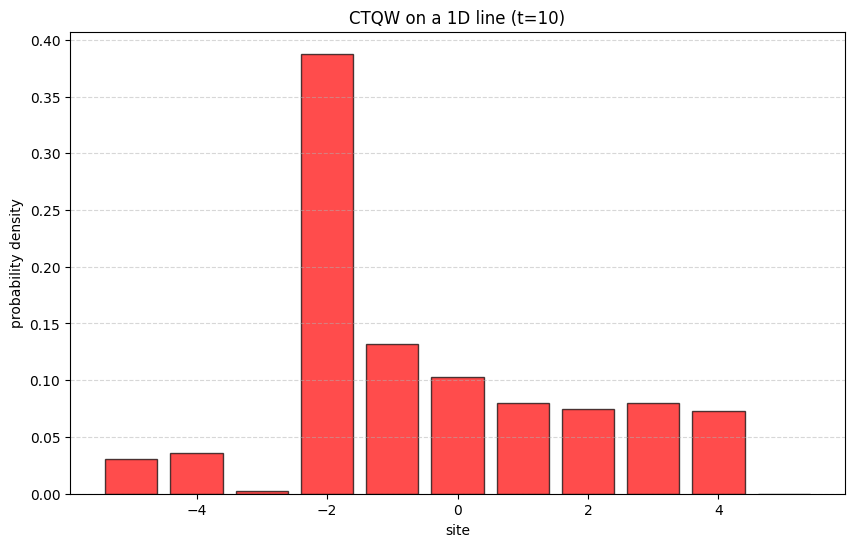

In [4]:
import numpy as np # for doing stuff with numbers
import matplotlib.pyplot as plt # for plotting
from scipy.linalg import expm # this we need for the time evolution operator


########################################## PROJECTIVE MEASUREMENT FUNCTION

import random
random.seed(13)

def on_site_PVM(state, target_site):

    prob_success = np.abs(state[target_site]) ** 2
    collapsed_state = np.zeros_like(state) # that is, np.zeros(len(psi), dtype=psi.dtype)

    if (random.random()>=prob_success):
        print(f"Walker is NOT at site {target_site-half_length}.")
        # projecting on the complementary subspace
        collapsed_state = state.copy()
        collapsed_state[target_site] = 0.0 
        # renormalize
        norm = np.linalg.norm(collapsed_state)
        if norm > 0:
            collapsed_state = collapsed_state/norm
    else:
        print(f"Success! Walker at site {target_site-half_length}.")
        collapsed_state[target_site] = state[target_site] / np.sqrt(prob_success)

    return collapsed_state



##########################################
##########################################
########################################## MAIN CODE
##########################################
##########################################

##########################################
# 1. define parameters for a qw on a line
##########################################
half_length = 5
num_sites = 2 * half_length + 1
center = half_length
t = 10 # duration of the evolution

##########################################
# 2. Laplacian matrix for a 1D line (L = D - A)
##########################################
# on-site energies
diag = 2 * np.eye(num_sites)
# first neighbor hopping
upper_diag = -1 * np.eye(num_sites, k=1)
lower_diag = -1 * np.eye(num_sites, k=-1)
# sum
L = diag + upper_diag + lower_diag
# add periodic boundary conditions (it becomes a ring...)
L[0,-1] = -1
L[-1,0] = -1
# check 
print(L)

##########################################
# 3. initialization of the state
##########################################

psi_0 = np.zeros(num_sites, dtype=complex)
psi_0[center] = 1.0 # start at the very center with no global phase

##########################################
# 4. time evolution (time-indep. H) + PVM
##########################################
gamma = 1.0 # hopping rate
H = gamma * L
interval = 0.1 # measure once every (interval) 
U = expm(-1j * H * interval) # evolution time step

time = 0.0 # initialize evolution
psi_step = psi_0 # initialize state by copying initial condition
while(time<t):
    time += interval
    psi_step = np.dot(U,psi_step) # free evolution - UNITARY
    psi_step = on_site_PVM(psi_step, int(center+half_length)) # measurement step


##########################################
# 5. probabilities calculation
##########################################
probabilities = np.abs(psi_step) ** 2 
# no need to project it: this is done INTERNALLY

##########################################
# 6. plot
##########################################
positions = np.arange(-half_length, half_length+1) # this is inherently a "vector"

plt.figure(figsize=(10, 6))
plt.bar(positions, probabilities, color = 'red', edgecolor = 'black', alpha = 0.7)
plt.title(f"CTQW on a 1D line (t={t})")
plt.xlabel("site")
plt.ylabel("probability density")
plt.grid(axis='y', linestyle='--',alpha=0.5)
plt.show()


##########################################
# USEFUL PARAMETERS
##########################################
# interval = 0.01 to recover zeno effect
